
## Data Extraction & Topological Cleaning

In [1]:
import vitaldb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, sosfiltfilt

# Nice plots
plt.rcParams['figure.figsize'] = (18, 5)
plt.rcParams['figure.dpi'] = 100

print('All imports OK ✅')

All imports OK ✅


---
## Case Discovery

We need a surgical case that contains:
- **SNUADC/PLETH** — Pulse waveform (plethysmography) at 500 Hz native
- **Primus/CO2** — Capnography waveform at 62.5 Hz native
- A clear **hypotension event** (sudden drop in mean arterial blood pressure)

Use `Solar8000/ART_MBP` (numeric mean arterial pressure) to locate the BP drop.

In [2]:
# Find cases that have BOTH required waveform tracks
required_tracks = ['SNUADC/PLETH', 'Primus/CO2']
candidate_ids = vitaldb.find_cases(required_tracks)
print(f'Found {len(candidate_ids)} cases with PLETH + CO2')

Found 6132 cases with PLETH + CO2


In [3]:
# Scan candidates for hypotension events (MBP < 65 mmHg)
# We'll check a manageable batch to find a good case quickly

BATCH_SIZE = 50  # check first N candidates
MBP_THRESHOLD = 65  # mmHg — clinical hypotension
MIN_HYPO_DURATION = 30  # seconds — at least 30s of sustained low BP

best_case = None
best_info = {}

for i, cid in enumerate(candidate_ids[:BATCH_SIZE]):
    try:
        # Load MBP at 1 Hz (numeric track, 1-second intervals)
        mbp_data = vitaldb.load_case(cid, ['Solar8000/ART_MBP'], 1)
        if mbp_data is None:
            continue
        mbp = mbp_data[:, 0]

        # Find sustained hypotension windows
        hypo_mask = mbp < MBP_THRESHOLD
        # Count consecutive True values
        valid_mbp = ~np.isnan(mbp)
        hypo_and_valid = hypo_mask & valid_mbp

        if hypo_and_valid.sum() >= MIN_HYPO_DURATION:
            # Find the longest hypotension segment
            hypo_times = np.where(hypo_and_valid)[0]
            # Calculate duration of surgery
            total_minutes = len(mbp) / 60

            # Get the center of the hypotension event
            hypo_center = int(np.median(hypo_times))
            min_mbp = float(np.nanmin(mbp[hypo_times]))

            print(f'  Case {cid}: surgery={total_minutes:.0f}min, '
                  f'hypo_samples={hypo_and_valid.sum()}, '
                  f'min_MBP={min_mbp:.1f}mmHg, '
                  f'event_center={hypo_center}s')

            if best_case is None or hypo_and_valid.sum() > best_info.get('hypo_count', 0):
                best_case = cid
                best_info = {
                    'hypo_count': int(hypo_and_valid.sum()),
                    'hypo_center_s': hypo_center,
                    'min_mbp': min_mbp,
                    'total_min': total_minutes,
                }
    except Exception as e:
        continue

print(f'\n✅ Best case: {best_case}')
print(f'   Details: {best_info}')

  Case 1: surgery=182min, hypo_samples=1261, min_MBP=-70.0mmHg, event_center=4440s


  Case 3: surgery=73min, hypo_samples=231, min_MBP=-11.0mmHg, event_center=4163s


  Case 4: surgery=350min, hypo_samples=1364, min_MBP=-61.0mmHg, event_center=10179s


  Case 7: surgery=254min, hypo_samples=733, min_MBP=-55.0mmHg, event_center=734s


  Case 10: surgery=349min, hypo_samples=2046, min_MBP=-23.0mmHg, event_center=8484s


...

  Case 44: surgery=244min, hypo_samples=611, min_MBP=-52.0mmHg, event_center=2108s


  Case 46: surgery=167min, hypo_samples=541, min_MBP=-33.0mmHg, event_center=546s


  Case 49: surgery=208min, hypo_samples=1408, min_MBP=-60.0mmHg, event_center=1425s


  Case 50: surgery=257min, hypo_samples=565, min_MBP=0.0mmHg, event_center=3489s


  Case 51: surgery=135min, hypo_samples=484, min_MBP=-13.0mmHg, event_center=489s

✅ Best case: 19
   Details: {'hypo_count': 4947, 'hypo_center_s': 12743, 'min_mbp': -31.0, 'total_min': 449.6}


---
## Data Extraction at 100 Hz

Extract `SNUADC/PLETH` and `Primus/CO2` at **100 Hz** (interval = 0.01s).
Then slice a **10-15 minute window** centered on the hypotension event.

In [4]:
# Load the two waveform tracks at 100 Hz
INTERVAL = 1 / 100  # 0.01 seconds — 100 Hz
tracks = ['SNUADC/PLETH', 'Primus/CO2']

raw = vitaldb.load_case(best_case, tracks, INTERVAL)
print(f'Raw data shape: {raw.shape}')
print(f'Duration: {raw.shape[0] * INTERVAL / 60:.1f} minutes')

Raw data shape: (2757521, 2)
Duration: 459.6 minutes


In [5]:
# Build time index
n_samples = raw.shape[0]
time = np.arange(n_samples) * INTERVAL

# Create DataFrame
df_full = pd.DataFrame({
    'Time': time,
    'PLETH': raw[:, 0],
    'CO2': raw[:, 1]
})

print(df_full.head())
print(f'\nTotal NaN per column:')
print(df_full.isna().sum())

   Time  PLETH  CO2
0  0.00    NaN  0.9
1  0.01    NaN  0.9
2  0.02    NaN  0.9
3  0.03    NaN  0.9
4  0.04    NaN  0.9

Total NaN per column:
Time       0
PLETH    426
CO2      686
dtype: int64


In [6]:
# Slice a 12-minute window (720 seconds) centered on the hypotension event
WINDOW_MINUTES = 12
WINDOW_SECONDS = WINDOW_MINUTES * 60
WINDOW_SAMPLES = WINDOW_SECONDS * 100  # at 100 Hz

# Center point in 100Hz samples
center_sample = best_info['hypo_center_s'] * 100

# Calculate start and end, clamped to valid range
start = max(0, center_sample - WINDOW_SAMPLES // 2)
end = min(n_samples, start + WINDOW_SAMPLES)
start = max(0, end - WINDOW_SAMPLES)  # re-adjust if we hit the end

df_window = df_full.iloc[start:end].copy().reset_index(drop=True)

# Re-build clean time column starting from 0
df_window['Time'] = np.arange(len(df_window)) * INTERVAL
df_window['Time'] = df_window['Time'].round(4)

print(f'Window: {len(df_window)} samples = {len(df_window)/100:.1f}s')
print(f'Time range: {df_window["Time"].iloc[0]:.2f}s → {df_window["Time"].iloc[-1]:.2f}s')
print(f'NaN per column:\n{df_window.isna().sum()}')

Window: 72000 samples = 720.0s
Time range: 0.00s → 719.99s
NaN per column:
Time     0
PLETH    0
CO2      0
dtype: int64


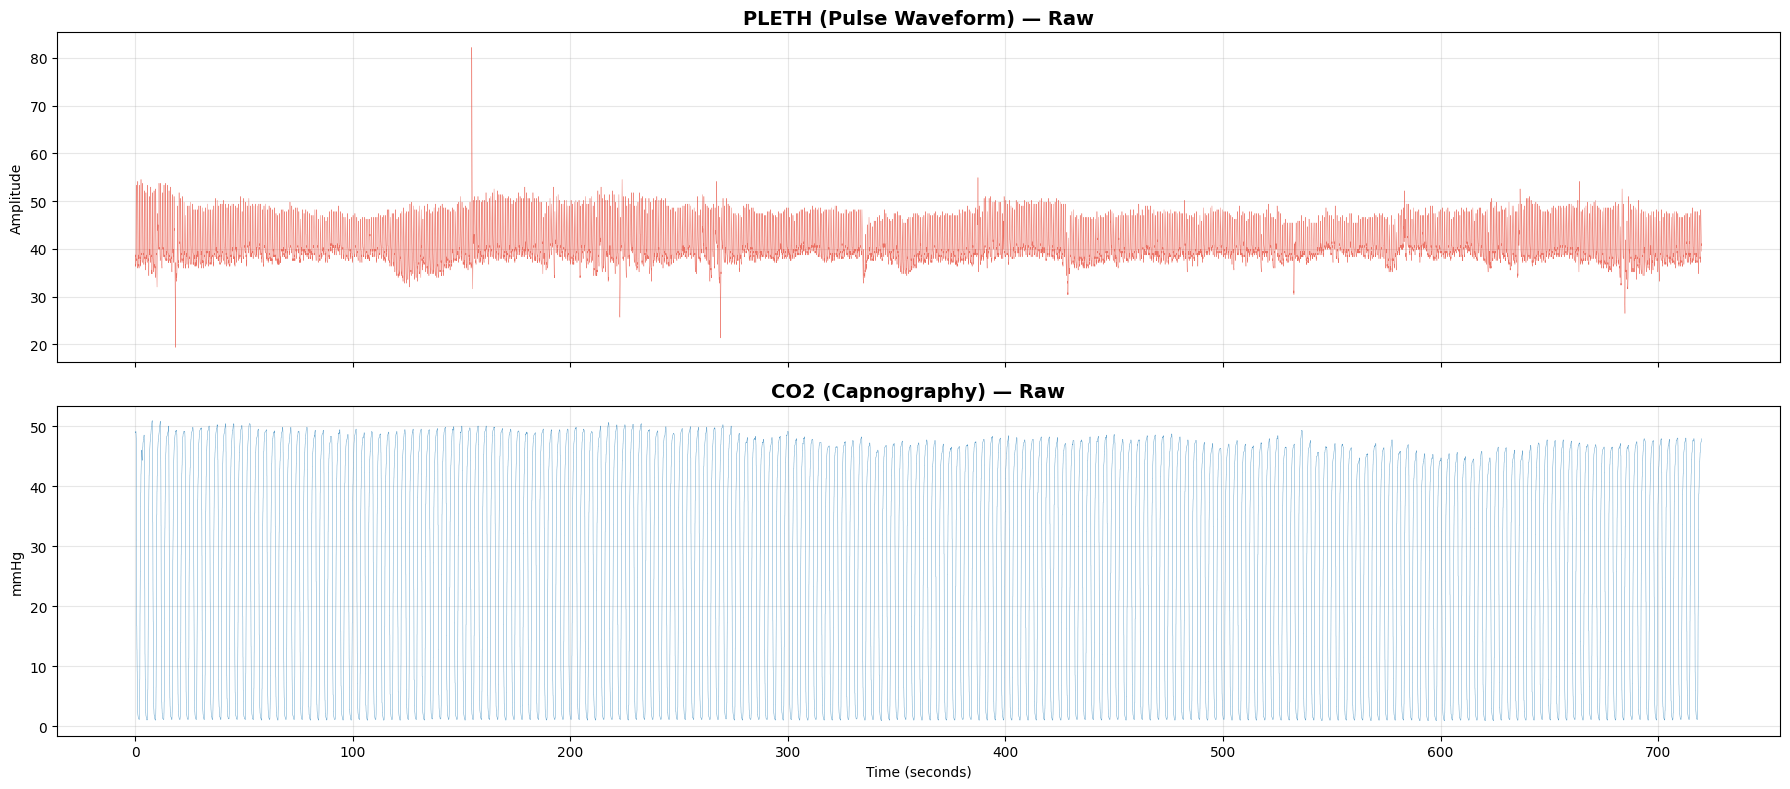

Saved raw_waveforms_overview.png ✅


In [7]:
# Quick plot of the raw window to verify we captured the event
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot(df_window['Time'], df_window['PLETH'], color='#e74c3c', linewidth=0.3, alpha=0.8)
axes[0].set_title('PLETH (Pulse Waveform) — Raw', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_window['Time'], df_window['CO2'], color='#2980b9', linewidth=0.3, alpha=0.8)
axes[1].set_title('CO2 (Capnography) — Raw', fontsize=14, fontweight='bold')
axes[1].set_ylabel('mmHg')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('raw_waveforms_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved raw_waveforms_overview.png ✅')

In [8]:
# Export raw CSV
df_window.to_csv('raw_surgical_data.csv', index=False)
print(f'Exported raw_surgical_data.csv ({len(df_window)} rows) ✅')

Exported raw_surgical_data.csv (72000 rows) ✅


---
## NaN Forward-Fill (Zero-Order Hold)

Hospital machines record at slightly different intervals, leaving gaps.
We apply **forward-fill** (copy last valid value into NaN slots), then **back-fill** for any leading NaNs.
The waveform must be mathematically continuous — no nulls allowed.

In [9]:
df_clean = df_window.copy()

print('NaN BEFORE fill:')
print(df_clean.isna().sum())
print()

# Forward-fill then back-fill
df_clean['PLETH'] = df_clean['PLETH'].ffill().bfill()
df_clean['CO2'] = df_clean['CO2'].ffill().bfill()

print('NaN AFTER fill:')
print(df_clean.isna().sum())

# Assertion — pipeline fails here if any NaN remains
assert df_clean.isna().sum().sum() == 0, 'ERROR: NaN values remain!'
print('\n✅ Zero-order hold complete — no NaN remaining')

NaN BEFORE fill:
Time     0
PLETH    0
CO2      0
dtype: int64

NaN AFTER fill:
Time     0
PLETH    0
CO2      0
dtype: int64

✅ Zero-order hold complete — no NaN remaining


---
## Butterworth Low-Pass Filter

Remove high-frequency electrical noise while preserving the shape of heartbeats and breaths.

| Signal | Cutoff | Rationale |
|--------|--------|-----------|
| PLETH  | 20 Hz  | Pulse wave harmonics up to ~15 Hz; keeps waveform shape |
| CO2    | 5 Hz   | Capnography is slower (~0.2-0.5 Hz fundamental); aggressive filtering safe |

We use `sosfiltfilt` for **zero-phase filtering** — no time-shift of peaks.

In [10]:
def apply_butterworth(signal, cutoff_hz, fs=100, order=4):
    """Apply a zero-phase Butterworth low-pass filter."""
    nyquist = fs / 2
    normalized_cutoff = cutoff_hz / nyquist
    sos = butter(order, normalized_cutoff, btype='low', output='sos')
    return sosfiltfilt(sos, signal)

# Apply filters
df_clean['PLETH_filtered'] = apply_butterworth(df_clean['PLETH'].values, cutoff_hz=20)
df_clean['CO2_filtered'] = apply_butterworth(df_clean['CO2'].values, cutoff_hz=5)

print('Butterworth filtering complete ✅')
print(f'  PLETH: 4th-order low-pass @ 20 Hz')
print(f'  CO2:   4th-order low-pass @ 5 Hz')

Butterworth filtering complete ✅
  PLETH: 4th-order low-pass @ 20 Hz
  CO2:   4th-order low-pass @ 5 Hz


---
## Verification

Compare raw vs. filtered on a **zoomed 2-second window**.
Verify that:
1. Heartbeat / breath peaks are in the **exact same time position**
2. High-frequency jaggedness (noise) is **removed**

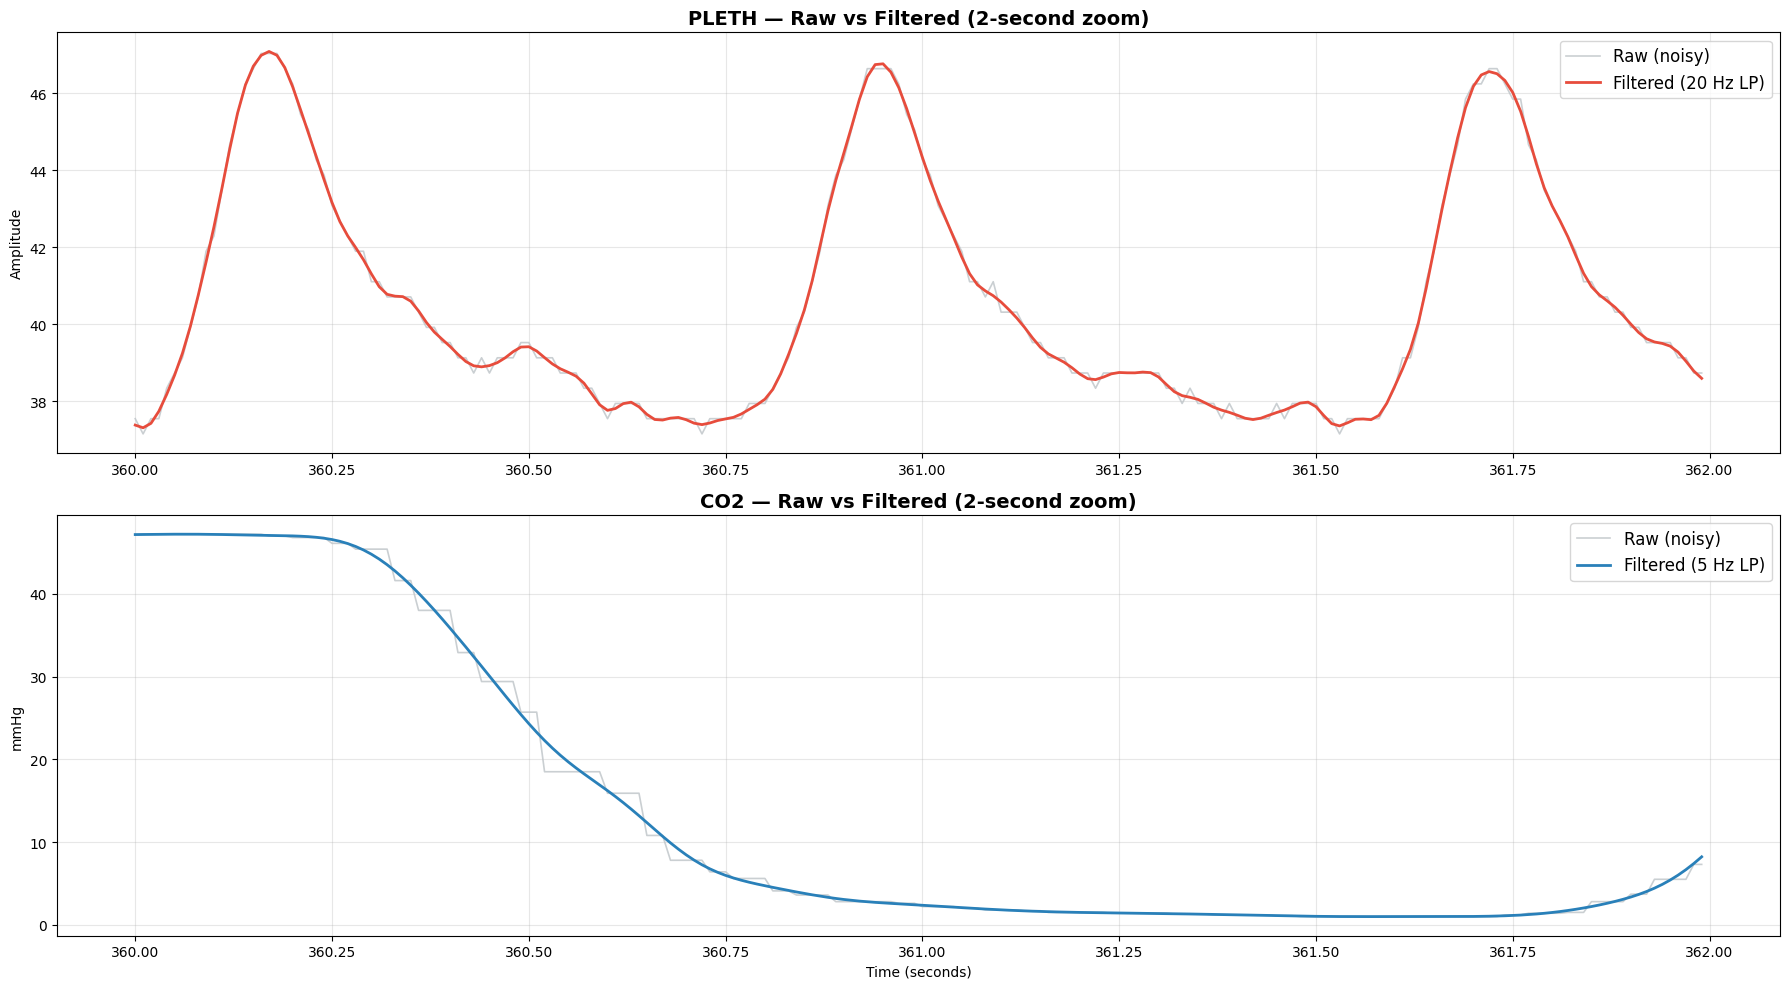

Saved filtered_vs_raw_verification.png ✅


In [11]:
# Pick a 2-second window in the middle of our data for verification
mid = len(df_clean) // 2
zoom_start = mid
zoom_end = mid + 200  # 2 seconds at 100 Hz

t = df_clean['Time'].iloc[zoom_start:zoom_end]

fig, axes = plt.subplots(2, 1, figsize=(18, 10))

# PLETH comparison
axes[0].plot(t, df_clean['PLETH'].iloc[zoom_start:zoom_end],
             color='#bdc3c7', linewidth=1.2, alpha=0.8, label='Raw (noisy)')
axes[0].plot(t, df_clean['PLETH_filtered'].iloc[zoom_start:zoom_end],
             color='#e74c3c', linewidth=2, label='Filtered (20 Hz LP)')
axes[0].set_title('PLETH — Raw vs Filtered (2-second zoom)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)

# CO2 comparison
axes[1].plot(t, df_clean['CO2'].iloc[zoom_start:zoom_end],
             color='#bdc3c7', linewidth=1.2, alpha=0.8, label='Raw (noisy)')
axes[1].plot(t, df_clean['CO2_filtered'].iloc[zoom_start:zoom_end],
             color='#2980b9', linewidth=2, label='Filtered (5 Hz LP)')
axes[1].set_title('CO2 — Raw vs Filtered (2-second zoom)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('mmHg')
axes[1].set_xlabel('Time (seconds)')
axes[1].legend(fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('filtered_vs_raw_verification.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved filtered_vs_raw_verification.png ✅')

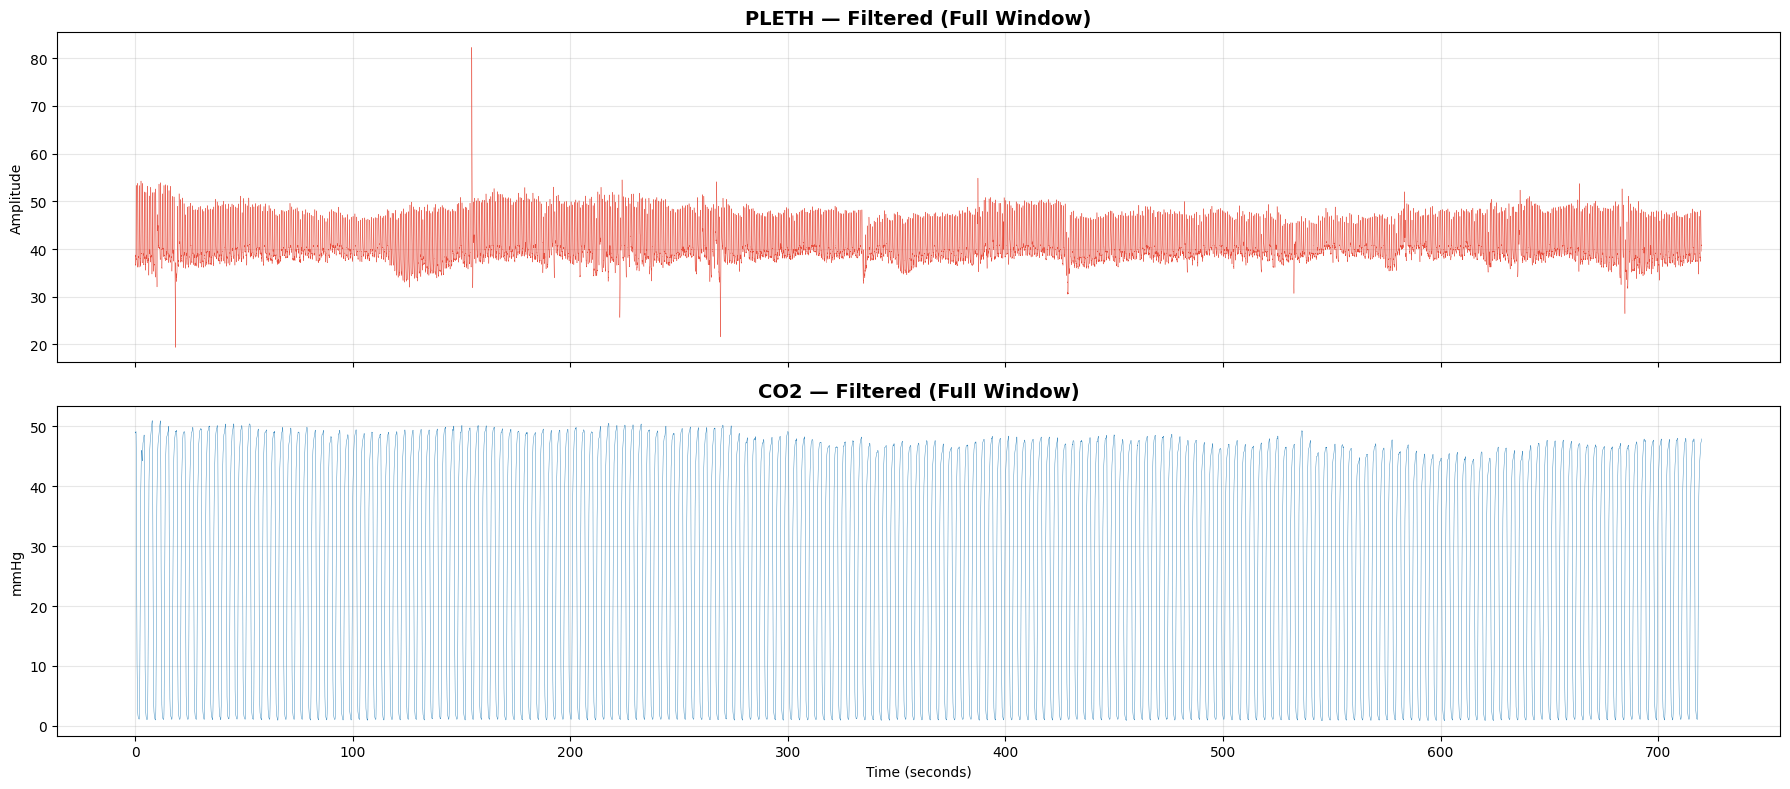

Saved filtered_waveforms_full.png ✅


In [12]:
# Full overview: filtered data across entire window
fig, axes = plt.subplots(2, 1, figsize=(18, 8), sharex=True)

axes[0].plot(df_clean['Time'], df_clean['PLETH_filtered'], color='#e74c3c', linewidth=0.3)
axes[0].set_title('PLETH — Filtered (Full Window)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

axes[1].plot(df_clean['Time'], df_clean['CO2_filtered'], color='#2980b9', linewidth=0.3)
axes[1].set_title('CO2 — Filtered (Full Window)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('mmHg')
axes[1].set_xlabel('Time (seconds)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('filtered_waveforms_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved filtered_waveforms_full.png ✅')

---
## Section 6 — Production Export

Final export: only `Time`, `PLETH`, `CO2` (filtered values). No NaN. Strict 0.01s time step.

In [13]:
# Build production DataFrame with filtered values
df_prod = pd.DataFrame({
    'Time': df_clean['Time'],
    'PLETH': df_clean['PLETH_filtered'],
    'CO2': df_clean['CO2_filtered']
})

# ── Final validation checks ──
print('═' * 50)
print('PRODUCTION DATA VALIDATION')
print('═' * 50)

# 1. No NaN
nan_count = df_prod.isna().sum().sum()
print(f'  NaN count:        {nan_count} {"✅" if nan_count == 0 else "❌"}')
assert nan_count == 0, 'FAIL: NaN values present!'

# 2. Correct columns
expected_cols = ['Time', 'PLETH', 'CO2']
cols_ok = list(df_prod.columns) == expected_cols
print(f'  Columns:          {list(df_prod.columns)} {"✅" if cols_ok else "❌"}')
assert cols_ok, f'FAIL: Expected {expected_cols}'

# 3. Time step consistency
time_diffs = df_prod['Time'].diff().dropna().round(4)
step_ok = (time_diffs == 0.01).all()
print(f'  Time step (0.01): {"consistent" if step_ok else "INCONSISTENT"} {"✅" if step_ok else "❌"}')
assert step_ok, 'FAIL: Time steps are not uniformly 0.01s!'

# 4. Row count
print(f'  Total rows:       {len(df_prod):,}')
print(f'  Duration:         {len(df_prod)/100:.1f} seconds = {len(df_prod)/100/60:.1f} minutes')
print(f'  Time range:       {df_prod["Time"].iloc[0]:.2f}s → {df_prod["Time"].iloc[-1]:.2f}s')

print('═' * 50)
print('ALL CHECKS PASSED ✅')
print('═' * 50)

══════════════════════════════════════════════════
PRODUCTION DATA VALIDATION
══════════════════════════════════════════════════
  NaN count:        0 ✅
  Columns:          ['Time', 'PLETH', 'CO2'] ✅
  Time step (0.01): consistent ✅
  Total rows:       72,000
  Duration:         720.0 seconds = 12.0 minutes
  Time range:       0.00s → 719.99s
══════════════════════════════════════════════════
ALL CHECKS PASSED ✅
══════════════════════════════════════════════════


In [14]:
# Export production CSV
df_prod.to_csv('production_sim_data.csv', index=False)
print(f'\n🚀 Exported production_sim_data.csv ({len(df_prod):,} rows)')
print(f'   File is ready for the high-speed simulator!')


🚀 Exported production_sim_data.csv (72,000 rows)
   File is ready for the high-speed simulator!
